# Train TD3 Diff Drive

Train the continuous differential-drive TD3 agent (Twin Delayed DDPG) and run a short greedy evaluation. Outputs are saved inside `Continuous_Diff_Drive/videos`, `Continuous_Diff_Drive/images`, and `Continuous_Diff_Drive/models`.

TD3 improves on DDPG with three tricks:
1. **Twin critics** — take `min(Q1, Q2)` in the TD target to reduce overestimation.
2. **Delayed actor updates** — update the actor (and target networks) every `policy_delay` critic updates.
3. **Target policy smoothing** — add clipped Gaussian noise to the target action so the critic does not over-fit narrow Q peaks.

In [1]:
from pathlib import Path
import sys

try:
    BASE_DIR = Path(__file__).resolve().parent
except NameError:
    BASE_DIR = Path.cwd()
    if BASE_DIR.name != "Continuous_Diff_Drive":
        BASE_DIR = BASE_DIR / "Continuous_Diff_Drive"

if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))

from diff_drive_agent import DiffDriveTD3Agent
from diff_drive_env import DiffDriveEnv

BASE_DIR

PosixPath('/Users/alessiotimofte/PycharmProjects/NAML_project/Continuous_Diff_Drive')

## Configuration

In [2]:
# A room with a few axis-aligned rectangular obstacles.
# Each obstacle is (x, y, width, height) in metres, origin at bottom-left.
OBSTACLES = [
    (2.0, 4.0, 1.5, 0.3),
    (5.0, 2.0, 0.3, 3.0),
    (7.0, 6.0, 1.5, 0.3),
]

ENV_KWARGS = dict(
    room_size       = (10.0, 10.0),
    obstacles       = None,
    random_obst     = True,
    robot_start     = (1.0, 1.0),
    goal_pos        = (8.5, 8.5),
    max_step        = 1000,
    n_lidar_rays    = 16,
    lidar_max_range = 5.0,
    robot_radius    = 0.3,
    dt              = 0.1,
    render_mode     = "rgb_array",
    obstacle_mode   = "curriculum",
)

NUM_EPISODES      = 5_000
RECORD_EVERY      = 500
LOG_EVERY         = 250

ACTOR_LR          = 1e-4
CRITIC_LR         = 1e-3
DISCOUNT          = 0.99    #both discount and tau tuned per-algorithm: DDPG's 0.995/0.001 hurt TD3 (its delayed updates compound with slow target tracking); 0.99/0.005 is TD3's working setting
TAU               = 0.005
POLICY_DELAY      = 2       # TD3-specific: actor updated every N critic updates
TARGET_NOISE_STD  = 0.2     # TD3-specific: stddev of target smoothing noise
TARGET_NOISE_CLIP = 0.5     # TD3-specific: clip target noise to +/- this
EXPL_NOISE_STD    = 0.2     # OU exploration stddev, raw action units (matches DDPG)
EXPL_NOISE_CLIP   = 0.5     # clip exploration noise to +/- this (matches DDPG)
BATCH_SIZE        = 256
BUFFER_SIZE       = 300_000
HIDDEN_DIM        = 256
WARMUP_STEPS      = 5_000
UPDATES_PER_STEP  = 2       # 2 gradient updates per env step (more sample-efficient). NOTE: DDPG uses 1, so this axis is NOT matched to DDPG
DEVICE            = "cpu"

RUN_TRAINING = True
LOAD_CHECKPOINT_FOR_EVAL = False

## Output Paths

In [3]:
VIDEO_DIR            = BASE_DIR / "videos"
TRAINING_VIDEO_DIR   = VIDEO_DIR / "training_td3"
EVALUATION_VIDEO_DIR = VIDEO_DIR / "evaluation_td3"
IMAGE_DIR            = BASE_DIR / "images"
MODEL_DIR            = BASE_DIR / "models"
CHECKPOINT_PATH      = MODEL_DIR / "td3_checkpoint.pt"
PLOT_PATH            = IMAGE_DIR / "td3_diff_drive_training_curves.png"
PLOT_PATH2           = IMAGE_DIR / "td3_diff_drive_training_curves2.png"

TRAINING_NAME_PREFIX   = "td3_diff_drive_training_random_obstacles"
EVALUATION_NAME_PREFIX = "td3_diff_drive_eval_random_obstacles_greedy"

for directory in (TRAINING_VIDEO_DIR, EVALUATION_VIDEO_DIR, IMAGE_DIR, MODEL_DIR):
    directory.mkdir(parents=True, exist_ok=True)

VIDEO_DIR

PosixPath('/Users/alessiotimofte/PycharmProjects/NAML_project/Continuous_Diff_Drive/videos')

## Environment and Agent

In [4]:
env = DiffDriveEnv(**ENV_KWARGS)

agent = DiffDriveTD3Agent(
    env               = env,
    actor_lr          = ACTOR_LR,
    critic_lr         = CRITIC_LR,
    discount          = DISCOUNT,
    tau               = TAU,
    policy_delay      = POLICY_DELAY,
    target_noise_std  = TARGET_NOISE_STD,
    target_noise_clip = TARGET_NOISE_CLIP,
    expl_noise_std    = EXPL_NOISE_STD,
    expl_noise_clip   = EXPL_NOISE_CLIP,
    batch_size        = BATCH_SIZE,
    buffer_size       = BUFFER_SIZE,
    hidden_dim        = HIDDEN_DIM,
    warmup_steps      = WARMUP_STEPS,
    updates_per_step  = UPDATES_PER_STEP,
    device            = DEVICE,
)

agent

## Training

In [5]:
if RUN_TRAINING:
    print("=" * 60)
    print("  DiffDrive - TD3 Training")
    print(f"  Episodes      : {NUM_EPISODES}")
    print(f"  Warmup        : {WARMUP_STEPS} steps")
    print(f"  Buffer        : {BUFFER_SIZE}")
    print(f"  Batch size    : {BATCH_SIZE}")
    print(f"  Policy delay  : {POLICY_DELAY}")
    print(f"  Device        : {DEVICE}")
    print(f"  Videos        : {TRAINING_VIDEO_DIR}")
    print("=" * 60)

    agent.train_recorded(
        num_episodes    = NUM_EPISODES,
        video_folder    = TRAINING_VIDEO_DIR,
        record_every    = RECORD_EVERY,
        log_every       = LOG_EVERY,
        name_prefix     = TRAINING_NAME_PREFIX,
        checkpoint_path = CHECKPOINT_PATH,
        plot_path       = PLOT_PATH,
        plot_path2      = PLOT_PATH2,
    )
else:
    print("Training skipped.")

/Users/alessiotimofte/PycharmProjects/NAML_project/.venv/lib/python3.11/site-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /Users/alessiotimofte/PycharmProjects/NAML_project/Continuous_Diff_Drive/videos/training_td3 folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


  DiffDrive - TD3 Training
  Episodes      : 5000
  Warmup        : 5000 steps
  Buffer        : 300000
  Batch size    : 256
  Policy delay  : 2
  Device        : cpu
  Videos        : /Users/alessiotimofte/PycharmProjects/NAML_project/Continuous_Diff_Drive/videos/training_td3


TD3 Training:   5%|▌         | 250/5000 [06:44<3:03:00,  2.31s/it]

Episode   250 | avg reward: -86.35 | success: 0.34 | avg dist: 4.25 | actor loss: 25.5688 | critic loss: 25.9549 | buffer: 106305 | steps: 106305


TD3 Training:  10%|█         | 500/5000 [16:32<1:56:36,  1.55s/it]

...

TD3 Training:  95%|█████████▌| 4750/5000 [1:30:17<05:30,  1.32s/it]

Episode  4750 | avg reward: 104.32 | success: 0.85 | avg dist: 1.18 | actor loss: 5.9600 | critic loss: 36.3530 | buffer: 300000 | steps: 1355343


TD3 Training: 100%|██████████| 5000/5000 [1:34:06<00:00,  1.13s/it]

Episode  5000 | avg reward: 114.22 | success: 0.89 | avg dist: 1.14 | actor loss: 3.5345 | critic loss: 30.9921 | buffer: 300000 | steps: 1412845
TD3 checkpoint saved to /Users/alessiotimofte/PycharmProjects/NAML_project/Continuous_Diff_Drive/models/td3_checkpoint.pt


TD3 plot saved to /Users/alessiotimofte/PycharmProjects/NAML_project/Continuous_Diff_Drive/images/td3_diff_drive_training_curves.png
TD3 plot 2 saved to /Users/alessiotimofte/PycharmProjects/NAML_project/Continuous_Diff_Drive/images/td3_diff_drive_training_curves2.png


## Checkpoint Loading

In [6]:
if LOAD_CHECKPOINT_FOR_EVAL:
    if not CHECKPOINT_PATH.exists():
        raise FileNotFoundError(f"No checkpoint found at {CHECKPOINT_PATH}")
    agent.load_checkpoint(CHECKPOINT_PATH, load_optimizers=False)
else:
    print("Using the current in-memory agent for evaluation.")

Using the current in-memory agent for evaluation.


## Evaluation

In [7]:
agent.eval_recorded(
    video_folder = EVALUATION_VIDEO_DIR,
    name_prefix  = EVALUATION_NAME_PREFIX,
    n_episodes   = 3,
)

/Users/alessiotimofte/PycharmProjects/NAML_project/.venv/lib/python3.11/site-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /Users/alessiotimofte/PycharmProjects/NAML_project/Continuous_Diff_Drive/videos/evaluation_td3 folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


  TD3 eval ep 1: reward = 174.4 | steps = 110 | goal reached: yes
  TD3 eval ep 2: reward = 168.6 | steps = 125 | goal reached: yes
  TD3 eval ep 3: reward = 176.6 | steps = 106 | goal reached: yes


## Generated Artifacts

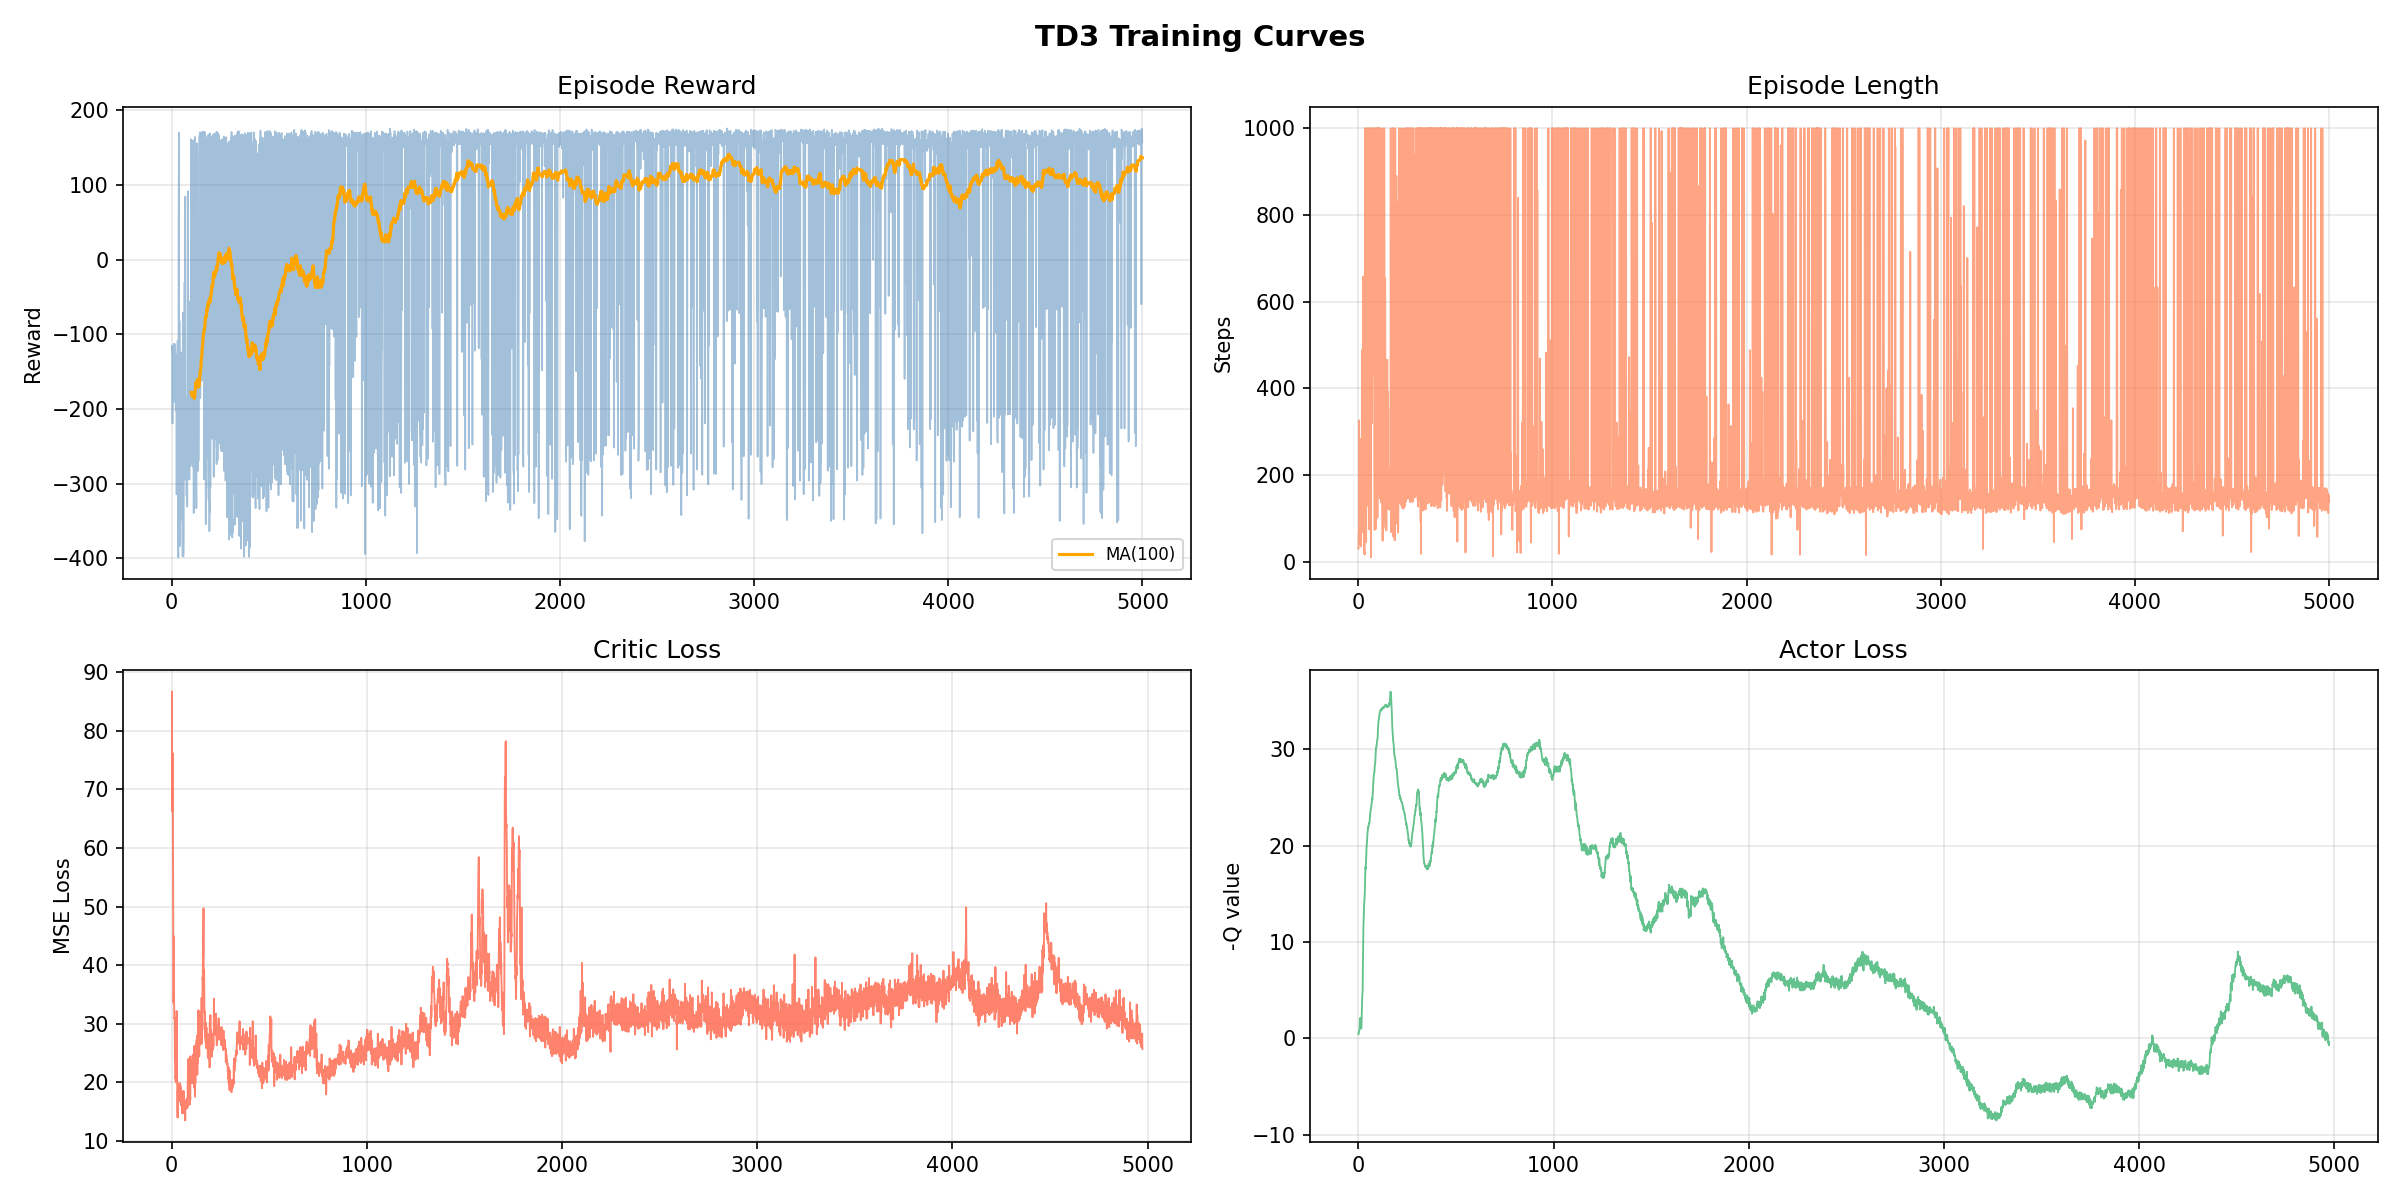

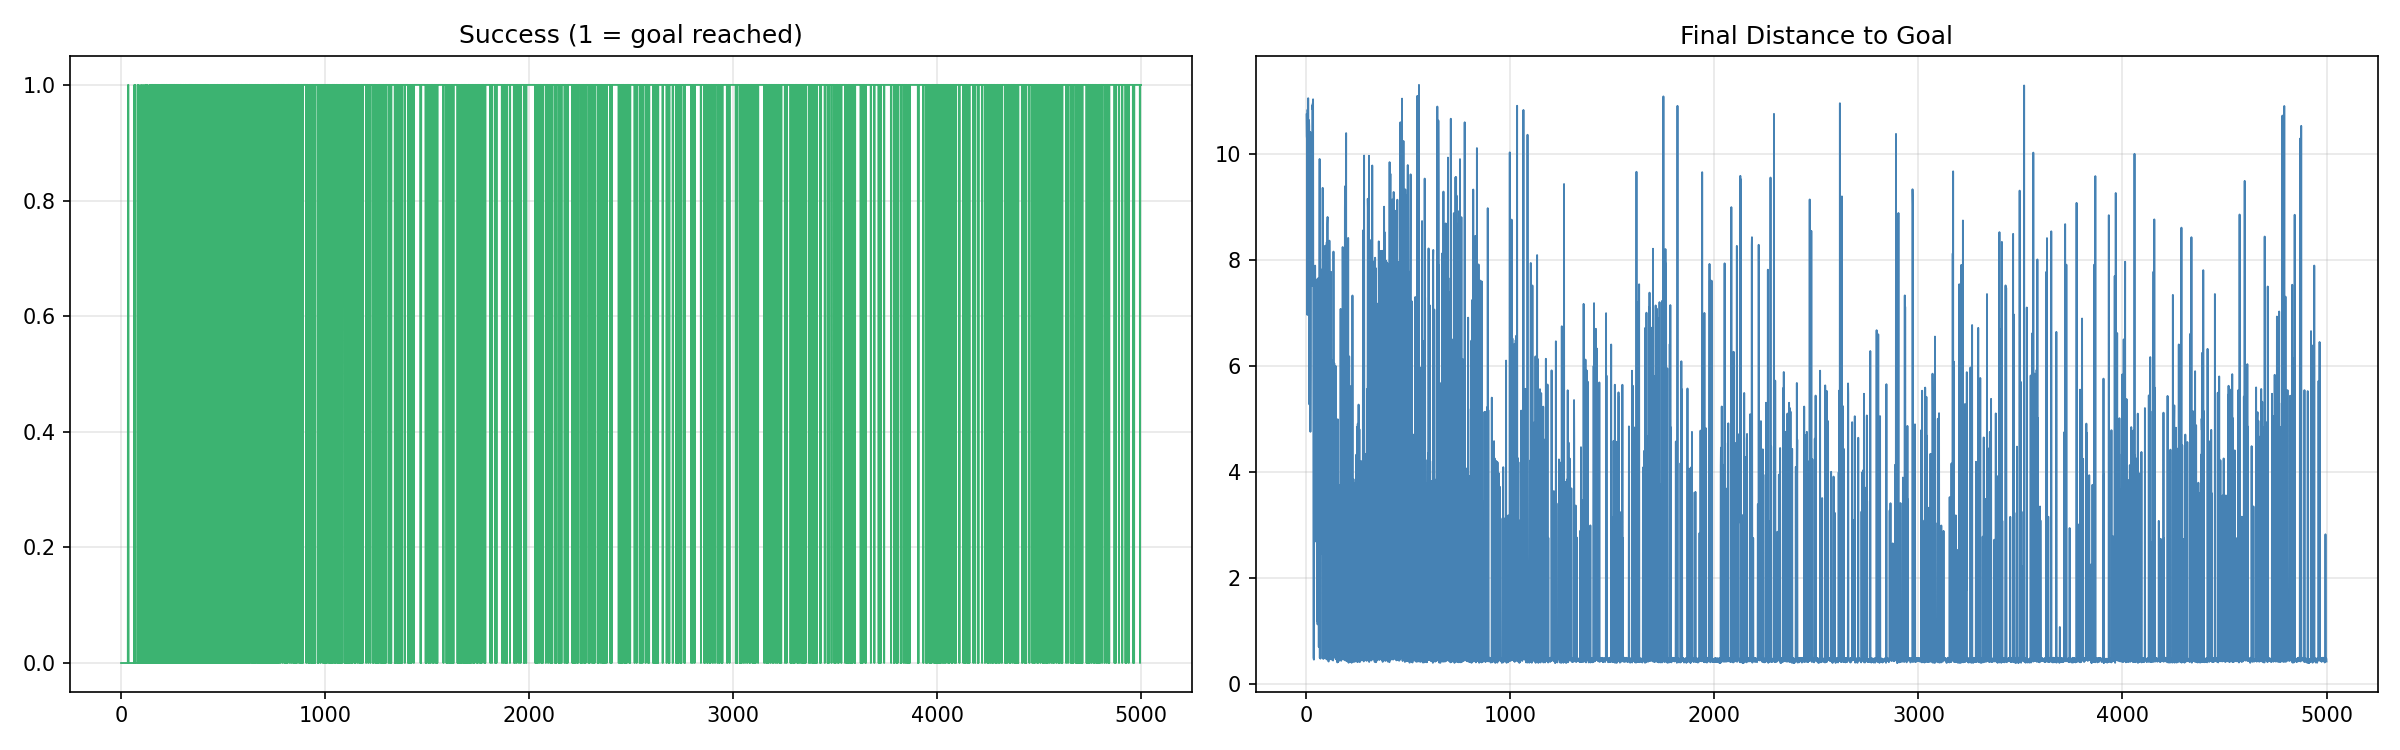

td3_diff_drive_training_random_obstacles-episode-0.mp4
td3_diff_drive_training_random_obstacles-episode-1000.mp4
td3_diff_drive_training_random_obstacles-episode-1500.mp4
td3_diff_drive_training_random_obstacles-episode-2000.mp4
td3_diff_drive_training_random_obstacles-episode-250.mp4
td3_diff_drive_training_random_obstacles-episode-2500.mp4
td3_diff_drive_training_random_obstacles-episode-3000.mp4
td3_diff_drive_training_random_obstacles-episode-3500.mp4
td3_diff_drive_training_random_obstacles-episode-4000.mp4
td3_diff_drive_training_random_obstacles-episode-4500.mp4
td3_diff_drive_training_random_obstacles-episode-500.mp4
td3_diff_drive_training_random_obstacles-episode-750.mp4
td3_diff_drive_eval_random_obstacles_greedy-episode-0.mp4


td3_diff_drive_eval_random_obstacles_greedy-episode-1.mp4


td3_diff_drive_eval_random_obstacles_greedy-episode-2.mp4


td3_diff_drive_eval_random_obstacles_greedy-episode-3.mp4


td3_diff_drive_eval_random_obstacles_greedy-episode-4.mp4


td3_diff_drive_eval_random_obstacles_greedy-episode-5.mp4


td3_diff_drive_eval_random_obstacles_greedy-episode-6.mp4


td3_diff_drive_eval_random_obstacles_greedy-episode-7.mp4


td3_diff_drive_eval_random_obstacles_greedy-episode-8.mp4


td3_diff_drive_eval_random_obstacles_greedy-episode-9.mp4


In [8]:
from IPython.display import Image, Video, display

if PLOT_PATH.exists():
    display(Image(filename=str(PLOT_PATH)))
if PLOT_PATH2.exists():
    display(Image(filename=str(PLOT_PATH2)))

for video_path in sorted(TRAINING_VIDEO_DIR.glob(f"{TRAINING_NAME_PREFIX}*.mp4")):
    print(video_path.name)

for video_path in sorted(EVALUATION_VIDEO_DIR.glob(f"{EVALUATION_NAME_PREFIX}*.mp4")):
    print(video_path.name)
    display(Video(filename=str(video_path), embed=True))